In [67]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [145]:
estaciones_sel = pd.read_csv("../data/data/MoreData/estaciones-seleccionadas.csv")
extraccion = pd.read_csv("../data/data/MoreData/extraccion_20260821-090338.csv", sep=";", low_memory=False)

print(estaciones_sel.shape, extraccion.shape)
estaciones_sel.head()

(383, 10) (6285, 35)


,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales


In [71]:
extraccion.head()

,id_muestra,nro_muestra,nombre_programa,id_programa,cue_nombre,id_cuenca,sub_cue_nombre,id_sub_cuenca,estacion,id_estacion,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,3255642,23951,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,90,XSLH030.S,100201,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,3.6,NaN,NaN,3.6
1,3255643,23952,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,160,EPSE020.S,100232,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,7.1,NaN,NaN,7.1
2,3255644,23953,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,159,EPSE030.S,100230,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,1.5,NaN,NaN,1.5
3,3255645,23954,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA CHICO,160,EPSE040.S,100231,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,3.3,NaN,NaN,3.3
4,3255651,23966,Agua rio Santa Lucia DCA,3,RÍO SANTA LUCÍA,6,RÍO SANTA LUCÍA hasta Río Santa Lucía Chico,84,XVIR050.S,100304,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,0.9,NaN,NaN,0.9


In [72]:
extraccion_chl_a = extraccion[(extraccion["parametro"] == "Clorofila_a_(lab)") & (extraccion["anio"] >= 2017) & (extraccion["id_tipo_punto"] == 1)].copy()

In [73]:
extraccion_chl_a.shape

(5019, 35)

In [74]:
sel_ids = set(estaciones_sel["id_estacion"])
ext_ids = set(extraccion["id_estacion"])

In [75]:
estaciones_gdf = gpd.GeoDataFrame(
    estaciones_sel,
    geometry=gpd.points_from_xy(estaciones_sel["longitud"], estaciones_sel["latitud"]),
    crs="EPSG:4326",
)
estaciones_gdf = estaciones_gdf[estaciones_gdf["id_tipo_punto"] == 1]
estaciones_gdf.head()

,nombre_programa,id_programa,estacion,id_estacion,latitud,longitud,id_tipo_punto,tip_pun_est_descripcion,id_matriz,nombre_matriz,geometry
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.41304 -32.9058)
1,Agua Arroyo Grande del Sur DCA,39,XGRS100.S,100625,-33.248939,-57.261889,1,SUPERFICIE,6,Aguas superficiales,POINT (-57.26189 -33.24894)
2,Agua Laguna Merin DCA,10,XYAG010.S,100286,-32.533749,-53.446399,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.4464 -32.53375)
3,Agua Laguna Merin DCA,10,XCEB005.S,100295,-33.829494,-54.768973,1,SUPERFICIE,6,Aguas superficiales,POINT (-54.76897 -33.82949)
4,Agua Laguna Merin DCA,10,XCEB030.S,100292,-33.158403,-53.651085,1,SUPERFICIE,6,Aguas superficiales,POINT (-53.65108 -33.1584)


In [76]:
estaciones_gdf["id_tipo_punto"].unique()

array([1])

In [116]:
OAN_registros = estaciones_gdf.merge(extraccion_chl_a,
                                          left_on = "id_estacion",
                                          right_on ="id_estacion",
                                          how = "inner"
                                          )#.drop(columns=["id_estacion"])

OAN_registros.head()

,nombre_programa_x,id_programa_x,estacion_x,id_estacion,latitud,longitud,id_tipo_punto_x,tip_pun_est_descripcion_x,id_matriz_x,nombre_matriz,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,2.600000000,0.700000000,2.2,2.600000000


In [117]:
OAN_registros.shape

(5019, 45)

In [118]:
type(OAN_registros)

geopandas.geodataframe.GeoDataFrame

In [119]:
#OAN_registros.to_file("../export/joins/OAN_registros.geojson", driver="GeoJSON")

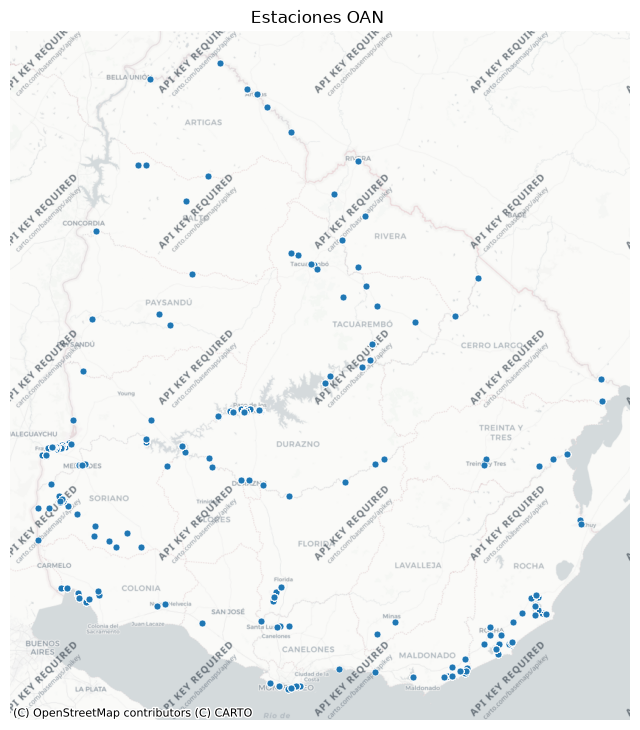

In [120]:
gdf_mapa = OAN_registros.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
gdf_mapa.plot(ax=ax, markersize=25, color="tab:blue", edgecolor="white", linewidth=0.5)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Estaciones OAN ")
plt.show()

In [121]:
OAN_registros.head()

,nombre_programa_x,id_programa_x,estacion_x,id_estacion,latitud,longitud,id_tipo_punto_x,tip_pun_est_descripcion_x,id_matriz_x,nombre_matriz,...,param,nombre_clave,parametro,grupo,id_unidad,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,40,XGRN100.S,100626,-32.905795,-57.413038,1,SUPERFICIE,6,Aguas superficiales,...,Clo_a,CloA_(lab),Clorofila_a_(lab),Biológicos,27,µg/L,2.600000000,0.700000000,2.2,2.600000000


### Queremos solo punto puntos de superficie

In [83]:
OAN_registros.columns

Index(['nombre_programa_x', 'id_programa_x', 'estacion_x', 'id_estacion',
       'latitud', 'longitud', 'id_tipo_punto_x', 'tip_pun_est_descripcion_x',
       'id_matriz_x', 'nombre_matriz', 'geometry', 'id_muestra', 'nro_muestra',
       'nombre_programa_y', 'id_programa_y', 'cue_nombre', 'id_cuenca',
       'sub_cue_nombre', 'id_sub_cuenca', 'estacion_y', 'id_tipo_punto_y',
       'tip_pun_est_descripcion_y', 'id_departamento', 'departamento',
       'id_institucion', 'institucion', 'periodo', 'anio', 'mes', 'anio_mes',
       'fecha_muestra', 'fecha_hora', 'observaciones', 'id_matriz_y',
       'id_parametro', 'param', 'nombre_clave', 'parametro', 'grupo',
       'id_unidad', 'uni_nombre', 'valor_original', 'limite_deteccion',
       'limite_cuantificacion', 'valor_transformado'],
      dtype='object')

In [84]:
for col in OAN_registros.columns:
    if "id_tipo" in col:
        print(col)

id_tipo_punto_x
id_tipo_punto_y


In [85]:
print(OAN_registros["estacion_y"].unique())

['XGRN100.S' 'XGRS100.S' nan 'XCEB030.S' 'XOLG020.S' 'XTAI030.S'
 'XSMI020.S' 'XYAG030.S' 'XSMI010.S' 'XCEB025.S' 'MDP1M' 'MDP2M' 'MDP4M'
 'MDP8M' 'MDP9M' 'MDP8S' 'MDP1S' 'MDP2S' 'MDP4S' 'MDP7S' 'MDP3M' 'MDP5S'
 'MDP6S' 'XCUA035.S' 'XCUA040.S' 'XCUA010.S' 'XCUA020.S' 'XCUA050.S'
 'XCUA060.S' 'XNEG150.S' 'XNEG087.S' 'XNEG100.S' 'EPPA120.S' 'EPPA130.S'
 'ERDB050.S' 'EBAY100.S' 'XNEG067.S' 'XNEG140.S' 'XNEG170.S' 'ERDB030.S'
 'EPPA110.S' 'XNEG005.S' 'XNEG060.S' 'XNEG020.S' 'XNEG160.S' 'XNEG010.S'
 'XNEG015.S' 'XNEG025.S' 'XSSA020.S' 'XSSA010.S' 'XSSA030.S' 'XSSA040.S'
 'XSSA050.S' 'XSSA060.S' 'XBIZ120.S' 'XSSA065.S' 'XAGU100.S' 'XSMA080.S'
 'XMAG110.S' 'XMAC090.S' 'XESP130.S' 'XCAG010.S' 'ECAG020.S' 'ECAG030.S'
 'EPSE020.S' 'EPSE030.S' 'EPSE040.S' 'XVIR050.S' 'XSLH030.S' 'ECAG015.S'
 'XTAC020.S' 'XTAH013.S' 'XTAH015.S' 'XCAR010.S' 'XCPU010.S' 'XCPU030.S'
 'XTAH020.S' 'XTAC030.S' 'XTAC040.S' 'XYAI010.S' 'XTAH010.S' 'XTAH005.S'
 'XCPU020.S' 'XTAC010.S' 'XTAH004.S' 'X0YI010.S' 'X0YI020.S' 'X

In [86]:
cols_para_borrar = [
    "id_tipo_punto_x",
    "id_tipo_punto_y",
    "id_programa_x",
    "id_programa_y",
    "id_matriz_x",
    "id_matriz_y",
    "tip_pun_est_descripcion_x",
    "tip_pun_est_descripcion_y",
    "sub_cue_nombre",
    "nombre_programa_y",
    "estacion_y",
    "nombre_matriz",
    "id_sub_cuenca",
    "id_cuenca",
    "observaciones",
    "anio",
    "mes",
    "anio_mes",
    "institucion",
    "id_institucion",
    "periodo",
    "anio_mes",
    "fecha_muestra",
    "id_parametro",
    "param",
    "parametro",
    "grupo",
    "id_unidad",
    "cue_nombre",
    "id_departamento",
    "latitud",
    "longitud",
    "id_muestra"
]

In [87]:
#nombre_programa_x N
#id_programa_x N
#estacion_x Y
#id_estacion Y
#latitud Y
#longitud Y
#id_tipo_punto_x N
#tip_pun_est_descripcion_x N
#id_matriz_x N 
#nombre_matriz N
#geometry Y 
#id_muestra Y
#nro_muestra Y
#nombre_programa_y N
#id_programa_y N
#cue_nombre N
#id_cuenca N
#sub_cue_nombre N
#id_sub_cuenca N
#estacion_y N
#id_tipo_punto_y N
#tip_pun_est_descripcion_y N
#id_departamento N
#departamento Y
#id_institucion N
#institucion N
#periodo N
#anio N
#mes N
#anio_mes N
#fecha_muestra N
#fecha_hora Y 
#observaciones N
#id_matriz_y N
#id_parametro N
#param N
#nombre_clave A
#parametro N
#grupo N
#id_unidad N
#uni_nombre Y
#valor_original Y
#limite_deteccion Y
#limite_cuantificacion Y
#valor_transformado Y

In [88]:
OAN_registros_clean = OAN_registros.drop(columns=cols_para_borrar)

In [89]:
OAN_registros_clean.head()

,nombre_programa_x,estacion_x,id_estacion,geometry,nro_muestra,departamento,fecha_hora,nombre_clave,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29873.0,RÍO NEGRO,2019-09-05 16:00:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29985.0,RÍO NEGRO,2019-10-31 09:40:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31062.0,RÍO NEGRO,2020-06-04 14:20:00,CloA_(lab),µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31410.0,RÍO NEGRO,2020-08-06 12:46:00,CloA_(lab),µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31851.0,RÍO NEGRO,2020-11-19 12:29:00,CloA_(lab),µg/L,2.600000000,0.700000000,2.2,2.600000000


In [90]:
OAN_registros_clean["nombre_programa_x"].unique()

array(['Agua Arroyo Grande del Norte DCA ',
       'Agua Arroyo Grande del Sur DCA', 'Agua Laguna Merin DCA',
       'Agua Montes del Plata Empresa', 'Agua Paysandu Intendencia',
       'Agua rio Cuareim DCA', 'Agua rio Negro DCA',
       'Agua rio San Salvador DCA', 'Agua rio Santa Lucia DCA',
       'Agua rio Tacuarembo DCA', 'Agua rio Yi DCA',
       'Agua Tributarios Río de la Plata', 'Agua Tributarios Río Uruguay',
       'Agua UPM1 DCA', 'Agua UPM2 Empresa', 'Laguna Blanca',
       'LAGUNA DE CASTILLOS', 'Laguna del Sauce', 'LAGUNA DE ROCHA',
       'Laguna Escondida', 'Laguna Garzon', 'Laguna José Ignacio',
       'Playa'], dtype=object)

In [91]:
puntos_laguna_rocha = OAN_registros_clean[OAN_registros_clean["nombre_programa_x"] == "LAGUNA DE ROCHA"]

In [92]:
OAN_registros_clean.groupby("nombre_programa_x").size()

nombre_programa_x
Agua Arroyo Grande del Norte DCA      15
Agua Arroyo Grande del Sur DCA        15
Agua Laguna Merin DCA                 99
Agua Montes del Plata Empresa        493
Agua Paysandu Intendencia              3
Agua Tributarios Río Uruguay          39
Agua Tributarios Río de la Plata      17
Agua UPM1 DCA                        481
Agua UPM2 Empresa                    970
Agua rio Cuareim DCA                 142
Agua rio Negro DCA                   427
Agua rio San Salvador DCA            316
Agua rio Santa Lucia DCA             274
Agua rio Tacuarembo DCA              254
Agua rio Yi DCA                       98
LAGUNA DE CASTILLOS                  330
LAGUNA DE ROCHA                      324
Laguna Blanca                          3
Laguna Escondida                       3
Laguna Garzon                        127
Laguna José Ignacio                  114
Laguna del Sauce                     483
Playa                                159
dtype: int64

In [93]:
puntos_laguna_rocha.explore(
    tiles="Esri.WorldImagery",
    marker_kwds={"radius": 8},
    color="red",
    zoom_start=16,
)

In [94]:
puntos_upm2 = OAN_registros_clean[OAN_registros_clean["nombre_programa_x"] == "Agua UPM2 Empresa"]

In [95]:
puntos_upm2.explore(
    tiles="Esri.WorldImagery",
    marker_kwds={"radius": 8},
    color="red",
    zoom_start=16,
)

In [193]:
puntos_laguna_sauce = OAN_registros_clean[OAN_registros_clean["nombre_programa_x"] == "Laguna del Sauce"]
puntos_laguna_sauce

,nombre_programa_x,estacion_x,id_estacion,geometry,nro_muestra,departamento,fecha_hora,nombre_clave,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
3976,Laguna del Sauce,TA,100270,POINT (-55.04207 -34.82973),0.0,MALDONADO,2017-01-02 00:00:00,CloA_(lab),µg/L,3.200,NaN,NaN,3.200
3977,Laguna del Sauce,TA,100270,POINT (-55.04207 -34.82973),0.0,MALDONADO,2017-01-04 00:00:00,CloA_(lab),µg/L,2.400,NaN,NaN,2.400
3978,Laguna del Sauce,TA,100270,POINT (-55.04207 -34.82973),0.0,MALDONADO,2017-01-09 00:00:00,CloA_(lab),µg/L,1.830,NaN,NaN,1.830
3979,Laguna del Sauce,TA,100270,POINT (-55.04207 -34.82973),0.0,MALDONADO,2017-01-11 00:00:00,CloA_(lab),µg/L,1.200,NaN,NaN,1.200
3980,Laguna del Sauce,TA,100270,POINT (-55.04207 -34.82973),0.0,MALDONADO,2017-01-12 00:00:00,CloA_(lab),µg/L,9.670,NaN,NaN,9.670
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4454,Laguna del Sauce,ARE,100283,POINT (-55.2001 -34.77954),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4455,Laguna del Sauce,ASN,100284,POINT (-55.03826 -34.75614),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4456,Laguna del Sauce,ASA2,100285,POINT (-55.07701 -34.785),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4457,Laguna del Sauce,LagAM,100603,POINT (-55.04729 -34.76011),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [194]:
puntos_laguna_sauce.explore(
    tiles="Esri.WorldImagery",
    marker_kwds={"radius": 8},
    color="red",
    zoom_start=16,
)

In [97]:
OAN_registros_clean.head()

,nombre_programa_x,estacion_x,id_estacion,geometry,nro_muestra,departamento,fecha_hora,nombre_clave,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29873.0,RÍO NEGRO,2019-09-05 16:00:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29985.0,RÍO NEGRO,2019-10-31 09:40:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31062.0,RÍO NEGRO,2020-06-04 14:20:00,CloA_(lab),µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31410.0,RÍO NEGRO,2020-08-06 12:46:00,CloA_(lab),µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31851.0,RÍO NEGRO,2020-11-19 12:29:00,CloA_(lab),µg/L,2.600000000,0.700000000,2.2,2.600000000


In [98]:
OAN_registros_clean = OAN_registros_clean.rename(columns={
    "nombre_programa_x": "nombre_programa",
    "estacion_x": "estacion"
})

In [99]:
OAN_registros_clean.head()

,nombre_programa,estacion,id_estacion,geometry,nro_muestra,departamento,fecha_hora,nombre_clave,uni_nombre,valor_original,limite_deteccion,limite_cuantificacion,valor_transformado
0,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29873.0,RÍO NEGRO,2019-09-05 16:00:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
1,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),29985.0,RÍO NEGRO,2019-10-31 09:40:00,CloA_(lab),µg/L,LD<x<LC,0.700000000,2.2,LD<x<LC
2,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31062.0,RÍO NEGRO,2020-06-04 14:20:00,CloA_(lab),µg/L,LD<X<LC,0.700000000,2.2,LD<X<LC
3,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31410.0,RÍO NEGRO,2020-08-06 12:46:00,CloA_(lab),µg/L,33.000000000,0.700000000,2.2,33.000000000
4,Agua Arroyo Grande del Norte DCA,XGRN100.S,100626,POINT (-57.41304 -32.9058),31851.0,RÍO NEGRO,2020-11-19 12:29:00,CloA_(lab),µg/L,2.600000000,0.700000000,2.2,2.600000000


In [105]:
#OAN_registros_clean.to_file("../export/oan/oan_registros_clean.geojson", driver="GeoJSON")

In [103]:
OAN_registros_clean["valor_original"].isnull().sum()

np.int64(176)

### GEMS chla


In [146]:
gems_params = pd.read_csv("../data/data/export/gemsparams.csv")
estaciones_gems = gpd.read_file("../data/data/export/estaciones.geojson")

print(gems_params.shape, estaciones_gems.shape)
gems_params.head()

(78759, 11) (258, 4)


,gems_param_id,location_id,code,fecha_inicio,fecha_fin,value,value_cat,unit,data_quality,depth,granularidad
0,da855a72-09d0-d78b-65ad-26bc18c98126,20b6e723-6bc5-052a-74da-b460cf6ac868,pH,2018-11-12 11:20:00,2018-11-13 11:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
1,2d3972e2-6442-807e-e91f-1532a1bffbce,20b6e723-6bc5-052a-74da-b460cf6ac868,pH,2018-11-12 23:20:00,2018-11-13 23:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
2,1533909e-d889-a8af-59b6-3c3f0e7c3ab2,20b6e723-6bc5-052a-74da-b460cf6ac868,pH,2018-11-21 10:30:00,2018-11-22 10:30:00,7.91,NaN,dimensionless,Fair,0.3,DIA
3,c2f43eb9-bff1-0fef-4661-894076336ac9,20b6e723-6bc5-052a-74da-b460cf6ac868,pH,2018-12-05 10:30:00,2018-12-06 10:30:00,8.00,NaN,dimensionless,Fair,0.3,DIA
4,2c908575-9a18-3441-7773-457a1caed73b,20b6e723-6bc5-052a-74da-b460cf6ac868,pH,2019-01-23 11:00:00,2019-01-24 11:00:00,7.59,NaN,dimensionless,Fair,0.3,DIA


In [123]:
estaciones_gems.head()

,nombre,type,id,geometry
0,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892)
1,Mercedes G3,METEO,e1f1c3a0-5d86-8d95-c20c-01d11eecd94d,POINT (-58.0305 -33.2524)
2,Artigas G3,METEO,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,POINT (-56.4667 -30.4)
3,Rocha G3,METEO,fca40b66-3095-bb02-f981-15365abf3389,POINT (-54.3333 -34.4833)
4,Colonia G3,METEO,1bf028c9-b910-8138-0f6d-e56ad8261159,POINT (-57.8398 -34.4626)


In [125]:
gems_chla = gems_params[(gems_params["code"] == "Chl-a") & (pd.to_datetime(gems_params["fecha_inicio"]).dt.year >= 2017)].copy()

gems_chla.shape

(3086, 11)

In [126]:
gems_registros = estaciones_gems.merge(gems_chla,
                                        left_on = "id",
                                        right_on = "location_id",
                                        how = "inner"
                                        )

gems_registros.head()

,nombre,type,id,geometry,gems_param_id,location_id,code,fecha_inicio,fecha_fin,value,value_cat,unit,data_quality,depth,granularidad
0,URY00006,GEMS,20b6e723-6bc5-052a-74da-b460cf6ac868,POINT (-55.3727 -34.5071),d02b7dc3-f9ca-b24f-7ce4-e8320d4411d7,20b6e723-6bc5-052a-74da-b460cf6ac868,Chl-a,2018-11-12 23:20:00,2018-11-13 23:20:00,0.0000,NaN,mg/l,Fair,0.3,DIA
1,URY00008,GEMS,41d6bec1-50a4-92cc-4978-08cddf641805,POINT (-55.2061 -34.4204),0c27abe5-d0a2-ac9c-c9ea-8651bbc288d4,41d6bec1-50a4-92cc-4978-08cddf641805,Chl-a,2018-11-12 08:30:00,2018-11-13 08:30:00,0.0000,NaN,mg/l,Fair,0.3,DIA
2,URY00029,GEMS,45c876a9-3c1b-13df-860f-8d058ae32031,POINT (-56.2355 -34.15748),ca4fedd3-7c09-7135-8446-24fbea76ad99,45c876a9-3c1b-13df-860f-8d058ae32031,Chl-a,2017-02-22 11:00:00,2017-02-23 11:00:00,0.0004,NaN,mg/l,Fair,0.3,DIA
3,URY00029,GEMS,45c876a9-3c1b-13df-860f-8d058ae32031,POINT (-56.2355 -34.15748),1cc87b22-5b16-ece4-679e-bd8d2499896b,45c876a9-3c1b-13df-860f-8d058ae32031,Chl-a,2017-04-19 13:00:00,2017-04-20 13:00:00,0.0007,NaN,mg/l,Fair,0.3,DIA
4,URY00029,GEMS,45c876a9-3c1b-13df-860f-8d058ae32031,POINT (-56.2355 -34.15748),f6fbba7b-4462-dedb-d3dd-75cf51a7fec4,45c876a9-3c1b-13df-860f-8d058ae32031,Chl-a,2017-12-13 11:44:00,2017-12-14 11:44:00,0.0286,NaN,mg/l,Fair,0.3,DIA


In [127]:
gems_registros.shape

(3086, 15)

In [128]:
gems_registros = gems_registros.rename(columns={
    "nombre": "estacion",
    "code": "param",
    "fecha_inicio": "fecha",
})
gems_registros["Decision"] = pd.NA

gems_registros = gems_registros[["estacion", "Decision", "param", "fecha", "value", "unit", "depth", "granularidad", "geometry"]]
gems_registros.head()

,estacion,Decision,param,fecha,value,unit,depth,granularidad,geometry
0,URY00006,<NA>,Chl-a,2018-11-12 23:20:00,0.0000,mg/l,0.3,DIA,POINT (-55.3727 -34.5071)
1,URY00008,<NA>,Chl-a,2018-11-12 08:30:00,0.0000,mg/l,0.3,DIA,POINT (-55.2061 -34.4204)
2,URY00029,<NA>,Chl-a,2017-02-22 11:00:00,0.0004,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)
3,URY00029,<NA>,Chl-a,2017-04-19 13:00:00,0.0007,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)
4,URY00029,<NA>,Chl-a,2017-12-13 11:44:00,0.0286,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)


In [129]:
gems_registros.to_file("../export/joins/gems_registros.geojson", driver="GeoJSON")

In [114]:
gems_registros["value"].isnull().sum()

np.int64(0)

In [136]:
oan_utm  = OAN_registros_clean.to_crs(32721).copy()
gems_utm = gems_registros.to_crs(32721).copy()

# --- Parte 1: puntos exactamente iguales ---
oan_utm['x']  = oan_utm.geometry.x.round()
oan_utm['y']  = oan_utm.geometry.y.round()
gems_utm['x'] = gems_utm.geometry.x.round()
gems_utm['y'] = gems_utm.geometry.y.round()

iguales = gems_utm.merge(
    oan_utm[['x', 'y', 'nombre_programa']],
    on=['x', 'y']
)
print('coordenadas únicas que coinciden:', 
      iguales[['x','y']].drop_duplicates().shape[0])


coordenadas únicas que coinciden: 150


In [137]:
print(gems_utm.columns.tolist())
print(oan_utm.columns.tolist())

['estacion', 'Decision', 'param', 'fecha', 'value', 'unit', 'depth', 'granularidad', 'geometry', 'x', 'y']
['nombre_programa', 'estacion', 'id_estacion', 'geometry', 'nro_muestra', 'departamento', 'fecha_hora', 'nombre_clave', 'uni_nombre', 'valor_original', 'limite_deteccion', 'limite_cuantificacion', 'valor_transformado', 'x', 'y']


In [147]:
oan_est  = oan_utm[['x','y','id_estacion']].drop_duplicates()
gems_est = gems_utm[['x','y','estacion' ]].drop_duplicates()

pares = gems_est.merge(oan_est, on=['x','y'], how='inner')

print(len(pares), 'estaciones que coinciden')
pares

150 estaciones que coinciden


,x,y,estacion,id_estacion
0,649386.0,6180413.0,URY00006,100012
1,664852.0,6189770.0,URY00008,100014
2,570470.0,6220119.0,URY00029,100201
3,581348.0,6603898.0,URY00031,100216
4,560699.0,6625270.0,URY00032,100217
...,...,...,...,...
145,518554.0,6362769.0,URY00228,100701
146,518473.0,6362067.0,URY00229,100702
147,697635.0,6136124.0,URY00243,100723
148,716874.0,6144492.0,URY00246,100726
